# Gemma-3-1B-it: Final Distillation Report

## What this experiment is

We took a very large, very capable AI model (**Qwen3-14B**, the "teacher") and used it to write worked solutions to grade-school math word problems (the GSM8K dataset). We then used those teacher-written solutions to train a much smaller AI model (**Gemma-3-1B**, the "student", about 14 times smaller) to solve the same kind of problems. This training process is called **fine-tuning** (specifically **QLoRA fine-tuning**, a memory-efficient version of it), and because the small model is learning by studying a bigger, smarter model's example answers, the overall approach is called **knowledge distillation**.

**Formal research question:** how effectively can knowledge distillation transfer mathematical reasoning capability from a large teacher model to a compact student model, while keeping that student cheap enough to actually run?

This notebook answers that through three more concrete questions:

- **How much transfers?** How much of the teacher's problem-solving ability survives the transfer into a model 14 times smaller?
- **Correct, or just correctly formatted?** Learning to *solve* the problems and learning to *format* the answer correctly are two different skills; did the student actually acquire both, and are they as tightly linked as they might seem?
- **What's the trade-off?** What does the student give up, in accuracy, in reliability, or in speed, to gain what it gains?

## What this notebook shows

This is the final report for the Gemma-3-1B student. It compares three things side by side, all measured on the same 1,319 held-out test math problems:

- **The teacher** (Qwen3-14B): a reference point for close to the best possible score.
- **Gemma before training** ("before SFT"): how it performs straight out of the box, with no fine-tuning.
- **Gemma after training** ("after SFT"): how it performs after learning from the teacher's worked examples.

It covers whether each model gets the right answer, whether its output follows the format required for automated grading, how efficient each model is to run, concrete worked examples pulled directly from the evaluation data, and a written conclusion tying everything together.

## Contents

1. [Headline results table](#1-headline-results-table)
2. [Accuracy and format compliance across stages](#2-accuracy-and-format-compliance-across-stages)
3. [Distillation effectiveness: deltas and gap to teacher](#3-distillation-effectiveness-deltas-and-gap-to-teacher)
4. [Where did the accuracy change come from? Regression vs improvement](#4-where-did-the-accuracy-change-come-from-regression-vs-improvement)
5. [Failure-mode breakdown, before vs after SFT](#5-failure-mode-breakdown-before-vs-after-sft)
6. [Efficiency: latency and throughput](#6-efficiency-latency-and-throughput)
7. [GPU memory, training cost, and model size](#7-gpu-memory-training-cost-and-model-size)
8. [Concrete examples](#8-concrete-examples)
9. [Output format compliance: before vs after SFT](#9-output-format-compliance-before-vs-after-sft)
10. [All metrics at a glance](#10-all-metrics-at-a-glance)
11. [Conclusion](#11-conclusion)

*(These links jump to the matching heading below. If a particular notebook viewer doesn't support in-page anchor links, just scroll, the section numbers still line up.)*

All numbers below are computed live from the metrics/prediction files in this project; nothing is hardcoded, so re-running this notebook re-derives every figure.

In [1]:
%matplotlib inline
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Colorblind-safe, consistent identity mapping used across every chart in this report:
# same color = same pipeline stage, everywhere.
PALETTE = {
    "teacher": "#2a78d6",
    "before_sft": "#eb6834",
    "after_sft": "#1baf7a",
}
STATUS = {
    "good": "#0ca30c",
    "critical": "#d03b3b",
}
INK = {
    "primary": "#0b0b0b",
    "secondary": "#52514e",
    "muted": "#898781",
    "grid": "#e1e0d9",
    "baseline": "#c3c2b7",
    "surface": "#fcfcfb",
}

plt.rcParams.update({
    "figure.facecolor": INK["surface"],
    "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["baseline"],
    "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"],
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "axes.grid": True,
    "grid.color": INK["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def style_ax(ax, horizontal=False):
    ax.set_axisbelow(True)
    ax.spines["left"].set_color(INK["baseline"])
    ax.spines["bottom"].set_color(INK["baseline"])
    if horizontal:
        ax.xaxis.grid(True)
        ax.yaxis.grid(False)
    else:
        ax.xaxis.grid(False)
        ax.yaxis.grid(True)

In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]


teacher_metrics = load_json("Teacher_Eval/Qwen_Qwen3-14B-AWQ_teacher_3cb9a5c9_metrics.json")
before_metrics = load_json(
    "gemma_before_sft_fp16_full/gemma_before_sft_fp16_full/google_gemma-3-1b-it_before_sft_c6683815_fp16_final_metrics.json"
)
after_metrics = load_json(
    "gemma_after_sft_fp16_full/google_gemma-3-1b-it_after_sft_3a9e3d53_fp16_full_final_metrics.json"
)
training_summary = load_json("gemma3_1b_qlora_v1/final_best_adapter/training_summary.json")

before_preds = load_jsonl(
    "gemma_before_sft_fp16_full/gemma_before_sft_fp16_full/google_gemma-3-1b-it_before_sft_c6683815_fp16_final_predictions.jsonl"
)
after_preds = load_jsonl(
    "gemma_after_sft_fp16_full/google_gemma-3-1b-it_after_sft_3a9e3d53_fp16_full_final_predictions.jsonl"
)

stage_data = {"teacher": teacher_metrics, "before_sft": before_metrics, "after_sft": after_metrics}

print(f"Teacher test examples: {teacher_metrics['total_examples']}")
print(f"Gemma before-SFT predictions: {len(before_preds)}")
print(f"Gemma after-SFT predictions: {len(after_preds)}")

Teacher test examples: 1319
Gemma before-SFT predictions: 1319
Gemma after-SFT predictions: 1319


## 1. Headline results table

All three pipeline stages, official GSM8K test split (n=1,319). `correct_and_valid_rate` requires both a right answer *and* a properly closed `<final_answer>` tag: the fair, apples-to-apples metric for judging distillation success (see section 3).

In [3]:
summary_df = pd.DataFrame([
    {
        "stage": "Teacher (Qwen3-14B-AWQ)",
        "exact_match_accuracy": teacher_metrics["exact_match_accuracy"],
        "valid_format_rate": teacher_metrics["valid_format_rate"],
        "correct_and_valid_rate": teacher_metrics["correct_and_valid_rate"],
        "avg_inference_seconds": teacher_metrics["average_inference_seconds"],
        "tokens_per_second": teacher_metrics["completion_tokens_per_second"],
        "peak_gpu_memory_gb": None,
    },
    {
        "stage": "Gemma-3-1B-it (before SFT)",
        "exact_match_accuracy": before_metrics["exact_match_accuracy"],
        "valid_format_rate": before_metrics["valid_format_rate"],
        "correct_and_valid_rate": before_metrics["correct_and_valid_rate"],
        "avg_inference_seconds": before_metrics["average_inference_seconds"],
        "tokens_per_second": before_metrics["completion_tokens_per_second"],
        "peak_gpu_memory_gb": before_metrics["peak_cuda_memory_bytes"] / 1e9,
    },
    {
        "stage": "Gemma-3-1B-it (after QLoRA SFT)",
        "exact_match_accuracy": after_metrics["exact_match_accuracy"],
        "valid_format_rate": after_metrics["valid_format_rate"],
        "correct_and_valid_rate": after_metrics["correct_and_valid_rate"],
        "avg_inference_seconds": after_metrics["average_inference_seconds"],
        "tokens_per_second": after_metrics["completion_tokens_per_second"],
        "peak_gpu_memory_gb": after_metrics["peak_cuda_memory_bytes"] / 1e9,
    },
]).set_index("stage")

display_df = summary_df.copy()
for col in ["exact_match_accuracy", "valid_format_rate", "correct_and_valid_rate"]:
    display_df[col] = (display_df[col] * 100).round(2).astype(str) + "%"
display_df["avg_inference_seconds"] = display_df["avg_inference_seconds"].round(2)
display_df["tokens_per_second"] = display_df["tokens_per_second"].round(1)
display_df["peak_gpu_memory_gb"] = display_df["peak_gpu_memory_gb"].round(3)
display_df

,exact_match_accuracy,valid_format_rate,correct_and_valid_rate,avg_inference_seconds,tokens_per_second,peak_gpu_memory_gb
stage,,,,,,
Teacher (Qwen3-14B-AWQ),92.27%,98.41%,91.36%,2.27,71.5,NaN
Gemma-3-1B-it (before SFT),51.4%,1.97%,0.99%,6.77,36.2,2.030
Gemma-3-1B-it (after QLoRA SFT),41.02%,97.35%,41.02%,17.09,12.3,2.095


## 2. Accuracy and format compliance across stages

Same color = same stage in every chart below (blue = teacher, orange = before SFT, aqua = after SFT).

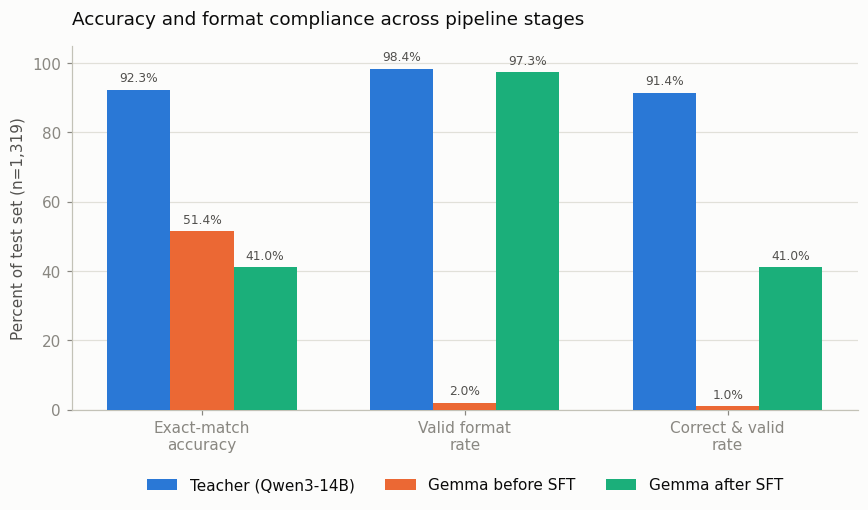

In [4]:
metrics_to_plot = ["exact_match_accuracy", "valid_format_rate", "correct_and_valid_rate"]
metric_labels = ["Exact-match\naccuracy", "Valid format\nrate", "Correct & valid\nrate"]
stages = ["teacher", "before_sft", "after_sft"]
stage_labels = ["Teacher (Qwen3-14B)", "Gemma before SFT", "Gemma after SFT"]

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=110)
n_metrics = len(metrics_to_plot)
n_stages = len(stages)
bar_width = 0.24
x = np.arange(n_metrics)

for i, stage in enumerate(stages):
    values = [stage_data[stage][m] * 100 for m in metrics_to_plot]
    offset = (i - (n_stages - 1) / 2) * bar_width
    bars = ax.bar(x + offset, values, width=bar_width, color=PALETTE[stage], label=stage_labels[i], zorder=3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", va="bottom",
                 fontsize=8, color=INK["secondary"])

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Percent of test set (n=1,319)")
ax.set_ylim(0, 105)
ax.set_title("Accuracy and format compliance across pipeline stages", loc="left", fontsize=12,
              color=INK["primary"], pad=14)
style_ax(ax)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

## 3. Distillation effectiveness: deltas and gap to teacher

In [5]:
abs_improvement_cav = (after_metrics["correct_and_valid_rate"] - before_metrics["correct_and_valid_rate"]) * 100
gap_to_teacher_cav = (teacher_metrics["correct_and_valid_rate"] - after_metrics["correct_and_valid_rate"]) * 100
retention_pct = after_metrics["correct_and_valid_rate"] / teacher_metrics["correct_and_valid_rate"] * 100
exact_match_delta = (after_metrics["exact_match_accuracy"] - before_metrics["exact_match_accuracy"]) * 100

display(Markdown(f"""
| Metric | Value |
|---|---|
| Absolute improvement over base model (correct & valid rate) | **+{abs_improvement_cav:.2f} pts** ({before_metrics['correct_and_valid_rate']*100:.2f}% → {after_metrics['correct_and_valid_rate']*100:.2f}%) |
| Absolute change in raw exact-match accuracy | **{exact_match_delta:+.2f} pts** ({before_metrics['exact_match_accuracy']*100:.2f}% → {after_metrics['exact_match_accuracy']*100:.2f}%) |
| Gap to teacher performance (correct & valid rate) | **{gap_to_teacher_cav:.2f} pts** |
| Teacher performance retained | **{retention_pct:.1f}%** |
"""))


| Metric | Value |
|---|---|
| Absolute improvement over base model (correct & valid rate) | **+40.03 pts** (0.99% → 41.02%) |
| Absolute change in raw exact-match accuracy | **-10.39 pts** (51.40% → 41.02%) |
| Gap to teacher performance (correct & valid rate) | **50.34 pts** |
| Teacher performance retained | **44.9%** |


## 4. Where did the accuracy change come from? Regression vs improvement

`exact_match_accuracy` fell after SFT. This section explains why, at the individual-question level, by matching before/after predictions on `problem_id`.

In [6]:
before_by_id = {d["problem_id"]: d for d in before_preds}
after_by_id = {d["problem_id"]: d for d in after_preds}

change_counts = {"improvement": 0, "regression": 0, "same_correct": 0, "same_wrong": 0}
for pid, a in after_by_id.items():
    b = before_by_id.get(pid)
    if b is None:
        continue
    if b["is_correct"] and a["is_correct"]:
        change_counts["same_correct"] += 1
    elif b["is_correct"] and not a["is_correct"]:
        change_counts["regression"] += 1
    elif not b["is_correct"] and a["is_correct"]:
        change_counts["improvement"] += 1
    else:
        change_counts["same_wrong"] += 1

total_matched = sum(change_counts.values())
net_change = change_counts["improvement"] - change_counts["regression"]
print(f"Matched questions: {total_matched}")
print(f"Net change: {net_change:+d} examples ({net_change/total_matched*100:+.2f} pts)")
print(f"This matches the {exact_match_delta:+.2f} pt exact-match delta from section 3.")

Matched questions: 1319
Net change: -137 examples (-10.39 pts)
This matches the -10.39 pt exact-match delta from section 3.


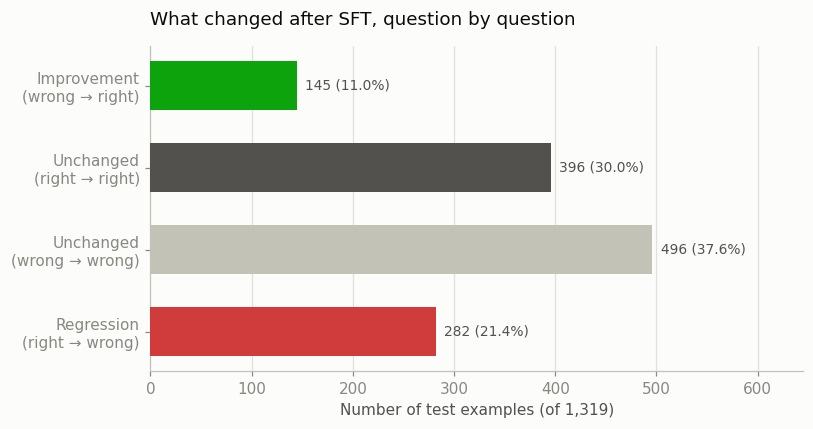

In [7]:
change_order = ["regression", "same_wrong", "same_correct", "improvement"]
change_display = {
    "regression": "Regression\n(right → wrong)",
    "improvement": "Improvement\n(wrong → right)",
    "same_correct": "Unchanged\n(right → right)",
    "same_wrong": "Unchanged\n(wrong → wrong)",
}
change_colors = {
    "regression": STATUS["critical"],
    "improvement": STATUS["good"],
    "same_correct": INK["secondary"],
    "same_wrong": INK["baseline"],
}

fig, ax = plt.subplots(figsize=(7.5, 4), dpi=110)
y = np.arange(len(change_order))
values = [change_counts[c] for c in change_order]
colors = [change_colors[c] for c in change_order]
bars = ax.barh(y, values, color=colors, zorder=3, height=0.6)
for bar, c in zip(bars, change_order):
    v = change_counts[c]
    ax.text(v + 8, bar.get_y() + bar.get_height() / 2, f"{v} ({v/total_matched*100:.1f}%)",
             va="center", fontsize=9, color=INK["secondary"])

ax.set_yticks(y)
ax.set_yticklabels([change_display[c] for c in change_order])
ax.set_xlabel("Number of test examples (of 1,319)")
ax.set_xlim(0, max(values) * 1.3)
ax.set_title("What changed after SFT, question by question", loc="left", fontsize=12,
              color=INK["primary"], pad=14)
style_ax(ax, horizontal=True)
plt.tight_layout()
plt.show()

## 5. Failure-mode breakdown, before vs after SFT

Counted from each prediction's `validation_errors` list (one example can carry multiple error tags).

In [8]:
def error_breakdown(preds):
    c = Counter()
    for d in preds:
        for err in d["validation_errors"]:
            c[err] += 1
    return c


before_errors = error_breakdown(before_preds)
after_errors = error_breakdown(after_preds)

all_error_types = sorted(
    set(before_errors) | set(after_errors),
    key=lambda k: -(before_errors.get(k, 0) + after_errors.get(k, 0)),
)
error_df = pd.DataFrame(
    {
        "before_sft": [before_errors.get(k, 0) for k in all_error_types],
        "after_sft": [after_errors.get(k, 0) for k in all_error_types],
    },
    index=all_error_types,
)
error_df

,before_sft,after_sft
wrong_answer,639,778
malformed_reasoning_tag,1292,34
malformed_final_answer_tag,522,0
missing_final_answer_tag,137,34
truncated_output,69,34
non_numeric_final_answer,3,1
ambiguous_final_answer,2,0


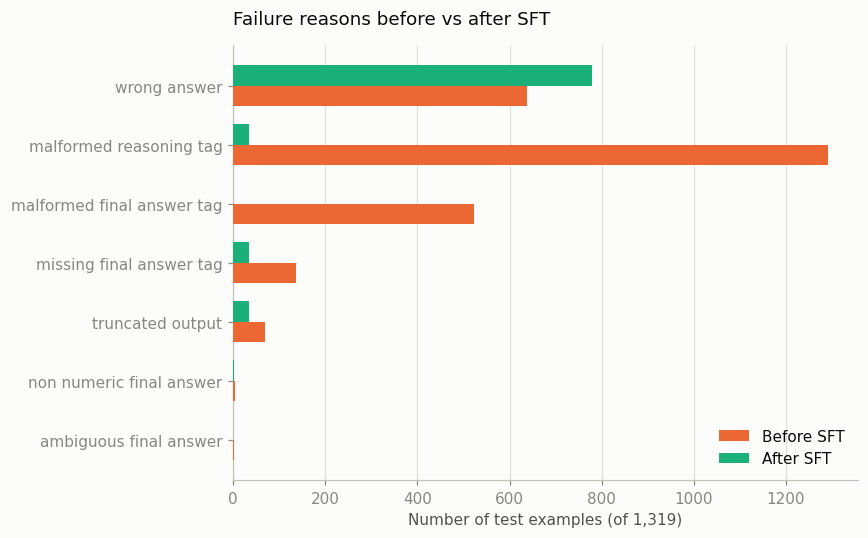

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=110)
y = np.arange(len(all_error_types))
bar_height = 0.35
ax.barh(y + bar_height / 2, error_df["before_sft"], height=bar_height, color=PALETTE["before_sft"],
         label="Before SFT", zorder=3)
ax.barh(y - bar_height / 2, error_df["after_sft"], height=bar_height, color=PALETTE["after_sft"],
         label="After SFT", zorder=3)

ax.set_yticks(y)
ax.set_yticklabels([e.replace("_", " ") for e in all_error_types])
ax.invert_yaxis()
ax.set_xlabel("Number of test examples (of 1,319)")
ax.set_title("Failure reasons before vs after SFT", loc="left", fontsize=12, color=INK["primary"], pad=14)
style_ax(ax, horizontal=True)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## 6. Efficiency: latency and throughput

**Caveat before reading this chart:** the teacher ran on a vLLM/OpenAI-compatible backend on dedicated inference hardware, while Gemma before/after ran on the `transformers` backend inside Colab, so those two are not directly comparable regardless of anything else. On top of that, the after-SFT Gemma run had to be **restarted partway through in Colab** (session disconnect/reconnect), which plausibly explains why it got *slower* despite generating *fewer* tokens on average (244.9 → 209.5 completion tokens) than before-SFT: a mid-run restart can land on a different GPU allocation, lose warm-up/caching state, and reset Colab's variable throttling, none of which reflects a real property of distillation or the LoRA adapter itself. Treat these latency/throughput numbers as reference points, not a controlled efficiency benchmark.

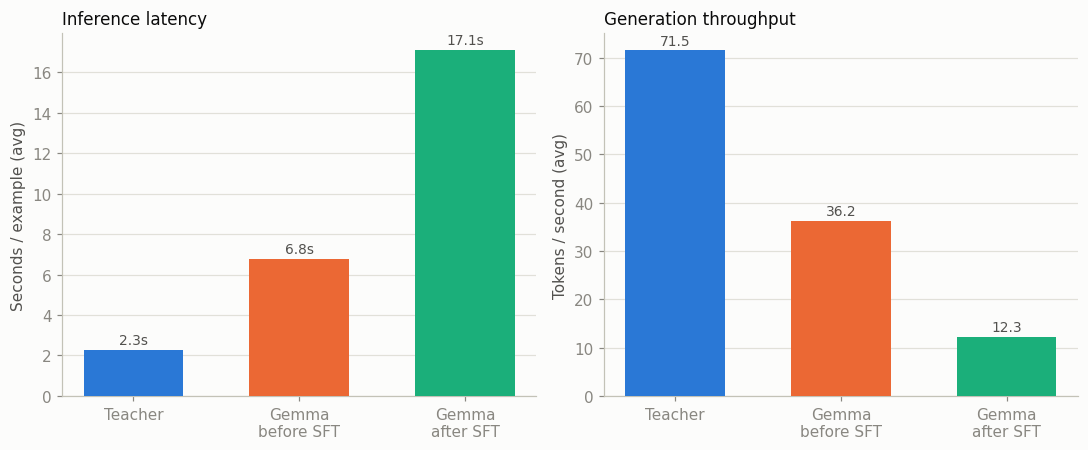

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=110)

stages_eff = ["teacher", "before_sft", "after_sft"]
stage_labels_eff = ["Teacher", "Gemma\nbefore SFT", "Gemma\nafter SFT"]
latency_vals = [stage_data[s]["average_inference_seconds"] for s in stages_eff]
throughput_vals = [stage_data[s]["completion_tokens_per_second"] for s in stages_eff]
colors_eff = [PALETTE[s] for s in stages_eff]

ax = axes[0]
bars = ax.bar(stage_labels_eff, latency_vals, color=colors_eff, zorder=3, width=0.6)
for bar, v in zip(bars, latency_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}s", ha="center", fontsize=9,
             color=INK["secondary"])
ax.set_ylabel("Seconds / example (avg)")
ax.set_title("Inference latency", loc="left", fontsize=11, color=INK["primary"])
style_ax(ax)

ax = axes[1]
bars = ax.bar(stage_labels_eff, throughput_vals, color=colors_eff, zorder=3, width=0.6)
for bar, v in zip(bars, throughput_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.2, f"{v:.1f}", ha="center", fontsize=9,
             color=INK["secondary"])
ax.set_ylabel("Tokens / second (avg)")
ax.set_title("Generation throughput", loc="left", fontsize=11, color=INK["primary"])
style_ax(ax)

plt.tight_layout()
plt.show()

## 7. GPU memory, training cost, and model size

(Teacher has no recorded GPU memory value: it ran behind an API-style serving backend, not measured the same way.)

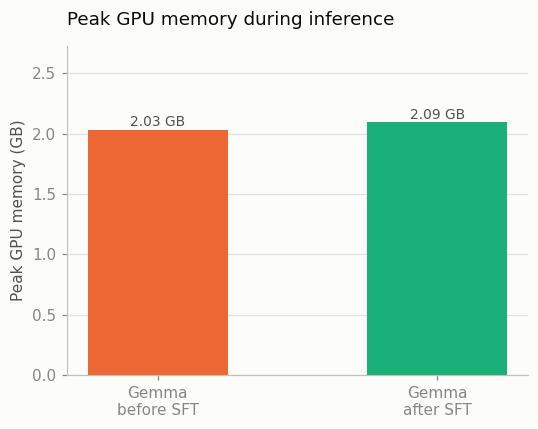

In [11]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=110)
mem_stages = ["before_sft", "after_sft"]
mem_vals = [stage_data[s]["peak_cuda_memory_bytes"] / 1e9 for s in mem_stages]
mem_colors = [PALETTE[s] for s in mem_stages]
bars = ax.bar(["Gemma\nbefore SFT", "Gemma\nafter SFT"], mem_vals, color=mem_colors, width=0.5, zorder=3)
for bar, v in zip(bars, mem_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03, f"{v:.2f} GB", ha="center", fontsize=9,
             color=INK["secondary"])
ax.set_ylabel("Peak GPU memory (GB)")
ax.set_ylim(0, max(mem_vals) * 1.3)
ax.set_title("Peak GPU memory during inference", loc="left", fontsize=12, color=INK["primary"], pad=14)
style_ax(ax)
plt.tight_layout()
plt.show()

In [12]:
adapter_storage_gb = after_metrics["model_metadata"]["adapter_storage_gb"]
base_params = before_metrics["model_metadata"]["parameter_count"]
trainable_params = training_summary["trainable_parameters"]
trainable_pct = trainable_params / base_params * 100
training_minutes = training_summary["trainer_train_runtime"] / 60

display(Markdown(f"""
| Training / storage metric | Value |
|---|---|
| Trainable parameters (QLoRA adapter) | {trainable_params:,} ({trainable_pct:.2f}% of {base_params:,} base params) |
| Adapter storage size | {adapter_storage_gb:.3f} GB |
| Training / validation examples | {training_summary['train_examples']:,} / {training_summary['validation_examples']:,} |
| Epochs | {training_summary['epochs']} |
| Total training time | {training_minutes:.1f} minutes ({training_summary['trainer_train_runtime']:.0f}s) |
| Best eval loss | {training_summary['best_eval_loss']:.4f} |
| LoRA rank / alpha | {training_summary['lora_r']} / {training_summary['lora_alpha']} |
"""))


| Training / storage metric | Value |
|---|---|
| Trainable parameters (QLoRA adapter) | 13,045,760 (1.30% of 999,885,952 base params) |
| Adapter storage size | 0.085 GB |
| Training / validation examples | 1,922 / 485 |
| Epochs | 3 |
| Total training time | 43.7 minutes (2621s) |
| Best eval loss | 0.1909 |
| LoRA rank / alpha | 16 / 32 |


## 8. Concrete examples

One regression (right → wrong) and one improvement (wrong → right), pulled live from the matched predictions.

In [13]:
def show_pair(pid, label):
    b, a = before_by_id[pid], after_by_id[pid]
    print("=" * 100)
    print(f"[{label}] {b['question']}")
    print(f"gold_answer: {b['gold_answer']}")
    print("\n--- BEFORE SFT ---")
    print(f"predicted: {b['predicted_answer']} ({'correct' if b['is_correct'] else 'wrong'})")
    print(b["raw_output"])
    print("\n--- AFTER SFT ---")
    print(f"predicted: {a['predicted_answer']} ({'correct' if a['is_correct'] else 'wrong'})")
    print(a["raw_output"])
    print()


regression_pids = [pid for pid, a in after_by_id.items()
                    if pid in before_by_id and before_by_id[pid]["is_correct"] and not a["is_correct"]]
improvement_pids = [pid for pid, a in after_by_id.items()
                     if pid in before_by_id and not before_by_id[pid]["is_correct"] and a["is_correct"]]

show_pair(regression_pids[0], "REGRESSION")
show_pair(improvement_pids[0], "IMPROVEMENT")

[REGRESSION] A new program had 60 downloads in the first month. The number of downloads in the second month was three times as many as the downloads in the first month, but then reduced by 30% in the third month. How many downloads did the program have total over the three months?
gold_answer: 366

--- BEFORE SFT ---
predicted: 366 (correct)
<reasoning>
Let $D_1$ be the number of downloads in the first month.
Let $D_2$ be the number of downloads in the second month.
Let $D_3$ be the number of downloads in the third month.

We are given that $D_1 = 60$.
The number of downloads in the second month was three times as many as the downloads in the first month, so $D_2 = 3 \times D_1 = 3 \times 60 = 180$.
The number of downloads in the second month was reduced by 30% in the third month, so $D_3 = D_2 - 0.30 \times D_2 = D_2(1 - 0.30) = 180(0.70) = 126$.
The total number of downloads over the three months is $D_1 + D_2 + D_3 = 60 + 180 + 126 = 366$.

<final_answer>366

--- AFTER SFT ---
predi

## 9. Output format compliance: before vs after SFT

The required output schema is a `<reasoning>...</reasoning>` block followed by `<final_answer>...</final_answer>` containing only the normalized numeric answer. This is the single metric that moved the most from SFT: `valid_format_rate` went from 1.97% to 97.35%, a roughly 49x increase. This section shows that jump directly, both as a chart and as raw model output.

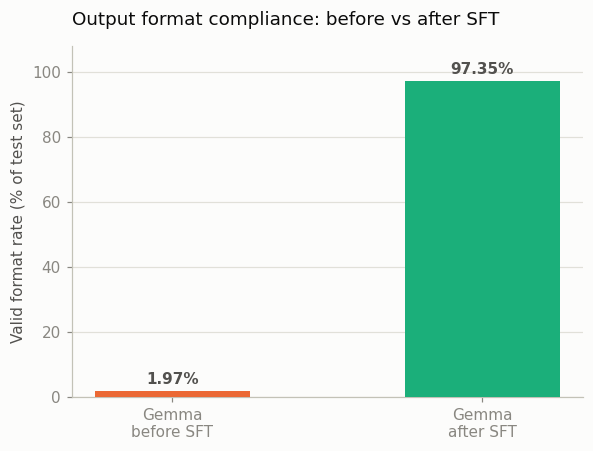

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 4.2), dpi=110)
fmt_stages = ["before_sft", "after_sft"]
fmt_labels = ["Gemma\nbefore SFT", "Gemma\nafter SFT"]
fmt_vals = [stage_data[s]["valid_format_rate"] * 100 for s in fmt_stages]
fmt_colors = [PALETTE[s] for s in fmt_stages]

bars = ax.bar(fmt_labels, fmt_vals, color=fmt_colors, width=0.5, zorder=3)
for bar, v in zip(bars, fmt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.2f}%", ha="center", fontsize=10,
             color=INK["secondary"], fontweight="bold")

ax.set_ylabel("Valid format rate (% of test set)")
ax.set_ylim(0, 108)
ax.set_title("Output format compliance: before vs after SFT", loc="left", fontsize=12,
              color=INK["primary"], pad=14)
style_ax(ax)
plt.tight_layout()
plt.show()

**In raw output.** Before SFT, the model rarely closed its tags properly, even when it got the math right (below left: no `</reasoning>` or `</final_answer>`, so the answer had to be rescued by fallback text-scanning). After SFT, the required schema is followed cleanly and consistently (below right).

In [15]:
# Pick a before-SFT example that got the right answer despite malformed tags, and an
# after-SFT example with a cleanly closed schema, to show the format shift directly.
before_malformed_correct = next(
    d for d in before_preds if d["is_correct"] and not d["is_valid_format"]
)
after_valid_correct = next(
    d for d in after_preds if d["is_correct"] and d["is_valid_format"]
)

print("=" * 100)
print("BEFORE SFT: malformed tags (answer_source:", before_malformed_correct["answer_source"], ")")
print("validation_errors:", before_malformed_correct["validation_errors"])
print("-" * 100)
print(before_malformed_correct["raw_output"])
print()
print("=" * 100)
print("AFTER SFT: clean, valid format (answer_source:", after_valid_correct["answer_source"], ")")
print("validation_errors:", after_valid_correct["validation_errors"])
print("-" * 100)
print(after_valid_correct["raw_output"])

BEFORE SFT: malformed tags (answer_source: fallback )
validation_errors: ['malformed_reasoning_tag', 'malformed_final_answer_tag']
----------------------------------------------------------------------------------------------------
<reasoning>
Let the number of bolts of blue fiber be $B$ and the number of bolts of white fiber be $W$.
We are given that the robe takes 2 bolts of blue fiber, so $B = 2$.
The robe takes half that much white fiber, which means $W = \frac{1}{2} \times B = \frac{1}{2} \times 2 = 1$.
The total number of bolts is the sum of the blue and white fibers, so $T = B + W = 2 + 1 = 3$.
The total number of bolts is 3.

<final_answer>3

AFTER SFT: clean, valid format (answer_source: final_answer_tag )
validation_errors: []
----------------------------------------------------------------------------------------------------
<reasoning>
Step 1: Janet lays 16 eggs per day.  
Step 2: She eats 3 eggs for breakfast every morning.  
Step 3: Subtract the eggs eaten for breakfast f

## 10. All metrics at a glance

Two tables:
1. **Stage comparison**: metrics measured for all three models (accuracy, format compliance, efficiency), side by side.
2. **Student (Gemma) training & distillation effectiveness**: metrics that only exist for the after-SFT run itself (there's nothing to compare across stages here, since the teacher was never trained by us, and the before-SFT model is just the untouched pretrained checkpoint).

### Table 1: Stage comparison (teacher vs before SFT vs after SFT)

In [16]:
def fmt_pct(x, decimals=2):
    return f"{x * 100:.{decimals}f}%" if x is not None else "—"


def fmt_num(x, suffix="", decimals=2):
    return f"{x:.{decimals}f}{suffix}" if x is not None else "—"


TEACHER_NOMINAL_PARAMS = "~14B (nominal figure, not measured directly; see note below)"

stage_rows = [
    ("Exact-match accuracy",
     fmt_pct(teacher_metrics["exact_match_accuracy"]),
     fmt_pct(before_metrics["exact_match_accuracy"]),
     fmt_pct(after_metrics["exact_match_accuracy"])),
    ("Valid format rate",
     fmt_pct(teacher_metrics["valid_format_rate"]),
     fmt_pct(before_metrics["valid_format_rate"]),
     fmt_pct(after_metrics["valid_format_rate"])),
    ("Correct & valid rate",
     fmt_pct(teacher_metrics["correct_and_valid_rate"]),
     fmt_pct(before_metrics["correct_and_valid_rate"]),
     fmt_pct(after_metrics["correct_and_valid_rate"])),
    ("95% CI (exact-match accuracy)",
     f"[{teacher_metrics['accuracy_ci_lower']*100:.1f}%, {teacher_metrics['accuracy_ci_upper']*100:.1f}%]",
     f"[{before_metrics['accuracy_ci_lower']*100:.1f}%, {before_metrics['accuracy_ci_upper']*100:.1f}%]",
     f"[{after_metrics['accuracy_ci_lower']*100:.1f}%, {after_metrics['accuracy_ci_upper']*100:.1f}%]"),
    ("Avg inference latency †",
     fmt_num(teacher_metrics["average_inference_seconds"], "s"),
     fmt_num(before_metrics["average_inference_seconds"], "s"),
     fmt_num(after_metrics["average_inference_seconds"], "s")),
    ("Throughput, tokens/sec †",
     fmt_num(teacher_metrics["completion_tokens_per_second"], "", 1),
     fmt_num(before_metrics["completion_tokens_per_second"], "", 1),
     fmt_num(after_metrics["completion_tokens_per_second"], "", 1)),
    ("Peak GPU memory *",
     "—",
     fmt_num(before_metrics["peak_cuda_memory_bytes"] / 1e9, " GB", 3),
     fmt_num(after_metrics["peak_cuda_memory_bytes"] / 1e9, " GB", 3)),
    ("Model parameter count *",
     TEACHER_NOMINAL_PARAMS,
     f"{before_metrics['model_metadata']['parameter_count']:,}",
     f"{after_metrics['model_metadata']['parameter_count']:,}"),
]

stage_comparison_df = pd.DataFrame(
    stage_rows, columns=["Metric", "Teacher (Qwen3-14B-AWQ)", "Gemma before SFT", "Gemma after SFT"]
).set_index("Metric")
stage_comparison_df.style.set_caption("Table 1: Stage Comparison (Teacher vs Before SFT vs After SFT)").set_table_styles(
    [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "1.05em"), ("text-align", "left"),
                                        ("padding-bottom", "6px")]}]
)

,Teacher (Qwen3-14B-AWQ),Gemma before SFT,Gemma after SFT
Metric,,,
Exact-match accuracy,92.27%,51.40%,41.02%
Valid format rate,98.41%,1.97%,97.35%
Correct & valid rate,91.36%,0.99%,41.02%
95% CI (exact-match accuracy),"[90.9%, 93.7%]","[48.5%, 54.1%]","[38.2%, 43.7%]"
Avg inference latency †,2.27s,6.77s,17.09s
"Throughput, tokens/sec †",71.5,36.2,12.3
Peak GPU memory *,—,2.030 GB,2.095 GB
Model parameter count *,"~14B (nominal figure, not measured directly; see note below)","999,885,952","1,012,931,712"


### Notes

- **\* Peak GPU memory / Model parameter count (teacher):** the teacher was evaluated by calling a vLLM server over an OpenAI-compatible API (`model_metadata.backend: "openai"`), not by loading the model in-process, so the eval script never had a handle on the serving process and couldn't record its GPU memory usage or introspect an exact parameter count the way it could for Gemma (loaded directly via `transformers`). "Peak GPU memory" is left blank for the teacher: genuinely not measured anywhere, with no reasonable proxy. "Model parameter count" instead shows the nominal ~14B figure from the Qwen3-14B model name/card, a published spec, not something this evaluation measured.

- **† Avg inference latency / Throughput:** not a controlled comparison across these three rows, for two separate reasons:
  1. The teacher ran on a different serving stack entirely (a vLLM server on dedicated inference hardware), while both Gemma runs used the plain `transformers` backend inside Colab, so teacher-vs-Gemma speed differences reflect infrastructure as much as the model itself.
  2. The after-SFT Gemma evaluation had to be restarted partway through in Colab (session disconnect/reconnect), which most likely explains why it measured slower (17.09s, 12.3 tok/s) than before-SFT (6.77s, 36.2 tok/s) despite generating shorter outputs on average (209 vs. 245 completion tokens); a mid-run restart can land on a different GPU allocation and lose warm-up state, which has nothing to do with the LoRA adapter or distillation itself. Full discussion in section 6.

### Table 2: Student (Gemma) training & distillation effectiveness

Only the after-SFT run has these values: there's no "before SFT" or "teacher" column here by definition.

In [17]:
student_rows = [
    ("Trainable parameters (QLoRA adapter)", f"{trainable_params:,} ({trainable_pct:.2f}% of base)"),
    ("Adapter storage size", f"{adapter_storage_gb:.3f} GB"),
    ("Training / validation examples",
     f"{training_summary['train_examples']:,} / {training_summary['validation_examples']:,}"),
    ("Epochs / LoRA rank, alpha",
     f"{training_summary['epochs']} / r={training_summary['lora_r']}, α={training_summary['lora_alpha']}"),
    ("Total training time", f"{training_minutes:.1f} min"),
    ("Best eval loss", f"{training_summary['best_eval_loss']:.4f}"),
    ("Improvement over base (correct & valid rate)", f"+{abs_improvement_cav:.2f} pts"),
    ("Change in raw exact-match accuracy", f"{exact_match_delta:+.2f} pts"),
    ("Gap to teacher (correct & valid rate)", f"{gap_to_teacher_cav:.2f} pts"),
    ("Teacher performance retained", f"{retention_pct:.1f}%"),
]

student_summary_df = pd.DataFrame(student_rows, columns=["Metric", "Value"]).set_index("Metric")
student_summary_df.style.set_caption("Table 2: Student (Gemma) Training & Distillation Effectiveness").set_table_styles(
    [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "1.05em"), ("text-align", "left"),
                                        ("padding-bottom", "6px")]}]
)

,Value
Metric,
Trainable parameters (QLoRA adapter),"13,045,760 (1.30% of base)"
Adapter storage size,0.085 GB
Training / validation examples,"1,922 / 485"
"Epochs / LoRA rank, alpha","3 / r=16, α=32"
Total training time,43.7 min
Best eval loss,0.1909
Improvement over base (correct & valid rate),+40.03 pts
Change in raw exact-match accuracy,-10.39 pts
Gap to teacher (correct & valid rate),50.34 pts


In [18]:
display(Markdown(f"""
## 11. Conclusion

This report set out to answer one question: after training Gemma-3-1B on the teacher's worked examples, how much did it actually learn, and what did it give up to learn it? Here's what the results show.

**What each metric below means:**

- **Valid format rate** — the percentage of answers that followed the exact structure required for automated processing: a `<reasoning>` block followed by a properly closed `<final_answer>` tag containing only the numeric answer.
- **Exact-match accuracy** — the percentage of answers where the extracted final number was correct, regardless of whether the surrounding output was properly formatted (a correct number salvaged from messy text still counts here).
- **Correct & valid rate** — the percentage of answers that were both correct *and* properly formatted. This is the more meaningful measure of real-world usability, since a correct answer buried in unparsable text can't actually be used by an automated system.

**Quick summary:**

| Metric | Teacher | Gemma before SFT | Gemma after SFT | Change (before → after) |
|---|---|---|---|---|
| Valid format rate | {teacher_metrics['valid_format_rate']*100:.1f}% | {before_metrics['valid_format_rate']*100:.1f}% | {after_metrics['valid_format_rate']*100:.1f}% | +{(after_metrics['valid_format_rate']-before_metrics['valid_format_rate'])*100:.1f} pts |
| Exact-match accuracy | {teacher_metrics['exact_match_accuracy']*100:.2f}% | {before_metrics['exact_match_accuracy']*100:.2f}% | {after_metrics['exact_match_accuracy']*100:.2f}% | {exact_match_delta:+.2f} pts |
| Correct & valid rate | {teacher_metrics['correct_and_valid_rate']*100:.2f}% | {before_metrics['correct_and_valid_rate']*100:.2f}% | {after_metrics['correct_and_valid_rate']*100:.2f}% | +{abs_improvement_cav:.2f} pts |

**Two follow-up questions the table above raises, and their answers:**

- *How much did training actually help?* — measured as the change in the student's correct & valid rate from before training to after.
- *How much better is the teacher, even after training?* — measured as the remaining difference between the teacher's correct & valid rate and the trained student's.

| Comparison | Calculation | Result |
|---|---|---|
| Training improvement (correct & valid rate) | {after_metrics['correct_and_valid_rate']*100:.2f}% (after) − {before_metrics['correct_and_valid_rate']*100:.2f}% (before) | +{abs_improvement_cav:.2f} pts |
| Gap to teacher (correct & valid rate) | {teacher_metrics['correct_and_valid_rate']*100:.2f}% (teacher) − {after_metrics['correct_and_valid_rate']*100:.2f}% (student, after training) | {gap_to_teacher_cav:.2f} pts |

**Format compliance improved substantially.**

Only {before_metrics['valid_format_rate']*100:.1f}% of answers were correctly formatted before training, compared with {after_metrics['valid_format_rate']*100:.1f}% afterward. This was the largest improvement observed: the model became reliable at producing output in the structure required for automated processing.

**Raw accuracy did not improve; by one measure, it fell.**

{change_counts['regression']} problems that were previously solved correctly are now incorrect after training; {change_counts['improvement']} previously incorrect problems are now correct, a net loss of {abs(net_change)} problems ({exact_match_delta:+.2f} points on plain right-or-wrong accuracy). Training did not improve the model's underlying math accuracy on this run.

**The most common new error was an arithmetic mistake, not a formatting failure.**

Before training, the model often solved problems using more flexible reasoning, for example, basic algebra. After training, it followed the required step-by-step format correctly, but occasionally made a small arithmetic error, such as treating "reduced by 30%" as "subtract 30" instead of "subtract 30% of the value." This suggests the change in output format was accompanied by a change in reasoning approach.

**By a fairer combined metric, correct and properly formatted, the model improved substantially.**

An answer that is correct but not properly formatted cannot be reliably used by an automated system. On this combined metric, performance improved from {before_metrics['correct_and_valid_rate']*100:.2f}% to {after_metrics['correct_and_valid_rate']*100:.2f}%, a gain of {abs_improvement_cav:.2f} points. This indicates that although raw accuracy did not improve, the model's output became significantly more usable.

**The gap to the teacher narrowed but remains substantial.**

The teacher scored {teacher_metrics['correct_and_valid_rate']*100:.2f}% on this combined metric; the student reached {retention_pct:.1f}% of that score, a {gap_to_teacher_cav:.2f}-point gap. This gap is expected, given the student has roughly 14 times fewer parameters than the teacher.

**Speed measurements are not directly comparable.**

The teacher and student were evaluated using different serving infrastructure, and the student's post-training evaluation was interrupted and restarted. These factors affect the measured speed independent of the model itself.

**Bottom line.**

Knowledge distillation succeeded decisively on one front and only partially on another. The student learned to express its answers in exactly the structure required, and on the fairest overall measure, correctness paired with usability, it improved substantially. What it did not gain was sharper problem-solving; if anything, raw accuracy slipped. For a compact, 1B-parameter model trained on a modest set of teacher demonstrations, output structure transferred readily; sound reasoning did not, at least not on this run. The two turn out to be separable capabilities, and this result argues for training and evaluating each one deliberately, rather than assuming one carries the other along with it.
"""))


## 11. Conclusion

This report set out to answer one question: after training Gemma-3-1B on the teacher's worked examples, how much did it actually learn, and what did it give up to learn it? Here's what the results show.

**What each metric below means:**

- **Valid format rate** — the percentage of answers that followed the exact structure required for automated processing: a `<reasoning>` block followed by a properly closed `<final_answer>` tag containing only the numeric answer.
- **Exact-match accuracy** — the percentage of answers where the extracted final number was correct, regardless of whether the surrounding output was properly formatted (a correct number salvaged from messy text still counts here).
- **Correct & valid rate** — the percentage of answers that were both correct *and* properly formatted. This is the more meaningful measure of real-world usability, since a correct answer buried in unparsable text can't actually be used by an automated system.

**Quick summary:**

| Metric | Teacher | Gemma before SFT | Gemma after SFT | Change (before → after) |
|---|---|---|---|---|
| Valid format rate | 98.4% | 2.0% | 97.3% | +95.4 pts |
| Exact-match accuracy | 92.27% | 51.40% | 41.02% | -10.39 pts |
| Correct & valid rate | 91.36% | 0.99% | 41.02% | +40.03 pts |

**Two follow-up questions the table above raises, and their answers:**

- *How much did training actually help?* — measured as the change in the student's correct & valid rate from before training to after.
- *How much better is the teacher, even after training?* — measured as the remaining difference between the teacher's correct & valid rate and the trained student's.

| Comparison | Calculation | Result |
|---|---|---|
| Training improvement (correct & valid rate) | 41.02% (after) − 0.99% (before) | +40.03 pts |
| Gap to teacher (correct & valid rate) | 91.36% (teacher) − 41.02% (student, after training) | 50.34 pts |

**Format compliance improved substantially.**

Only 2.0% of answers were correctly formatted before training, compared with 97.3% afterward. This was the largest improvement observed: the model became reliable at producing output in the structure required for automated processing.

**Raw accuracy did not improve; by one measure, it fell.**

282 problems that were previously solved correctly are now incorrect after training; 145 previously incorrect problems are now correct, a net loss of 137 problems (-10.39 points on plain right-or-wrong accuracy). Training did not improve the model's underlying math accuracy on this run.

**The most common new error was an arithmetic mistake, not a formatting failure.**

Before training, the model often solved problems using more flexible reasoning, for example, basic algebra. After training, it followed the required step-by-step format correctly, but occasionally made a small arithmetic error, such as treating "reduced by 30%" as "subtract 30" instead of "subtract 30% of the value." This suggests the change in output format was accompanied by a change in reasoning approach.

**By a fairer combined metric, correct and properly formatted, the model improved substantially.**

An answer that is correct but not properly formatted cannot be reliably used by an automated system. On this combined metric, performance improved from 0.99% to 41.02%, a gain of 40.03 points. This indicates that although raw accuracy did not improve, the model's output became significantly more usable.

**The gap to the teacher narrowed but remains substantial.**

The teacher scored 91.36% on this combined metric; the student reached 44.9% of that score, a 50.34-point gap. This gap is expected, given the student has roughly 14 times fewer parameters than the teacher.

**Speed measurements are not directly comparable.**

The teacher and student were evaluated using different serving infrastructure, and the student's post-training evaluation was interrupted and restarted. These factors affect the measured speed independent of the model itself.

**Bottom line.**

Knowledge distillation succeeded decisively on one front and only partially on another. The student learned to express its answers in exactly the structure required, and on the fairest overall measure, correctness paired with usability, it improved substantially. What it did not gain was sharper problem-solving; if anything, raw accuracy slipped. For a compact, 1B-parameter model trained on a modest set of teacher demonstrations, output structure transferred readily; sound reasoning did not, at least not on this run. The two turn out to be separable capabilities, and this result argues for training and evaluating each one deliberately, rather than assuming one carries the other along with it.
